In [1]:
%pip install datasets --upgrade

In [1]:

from datasets import load_dataset

# Load the GSM8K dataset
gsm8k_dataset = load_dataset("gsm8k", "main")
math_dataset = load_dataset("qwedsacf/competition_math", split="train")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

(…)-00000-of-00001-7320a6f3aba8ebd2.parquet:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12500 [00:00<?, ? examples/s]

In [2]:
gsm8k_test=gsm8k_dataset["test"]
gsm8k_train=gsm8k_dataset["train"]
tts = math_dataset.train_test_split(test_size=0.2,seed=79)

math_test=tts['test']
math_train=tts['train']

In [3]:
print(math_test)
print(math_train)
print(gsm8k_test)
print(gsm8k_train)

Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 2500
})
Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 10000
})
Dataset({
    features: ['question', 'answer'],
    num_rows: 1319
})
Dataset({
    features: ['question', 'answer'],
    num_rows: 7473
})


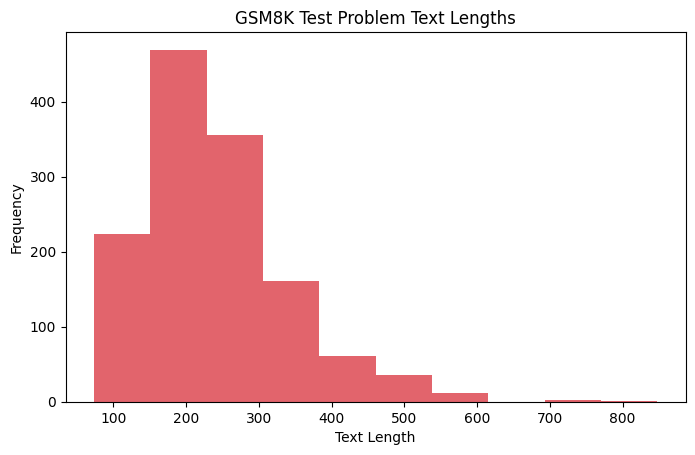

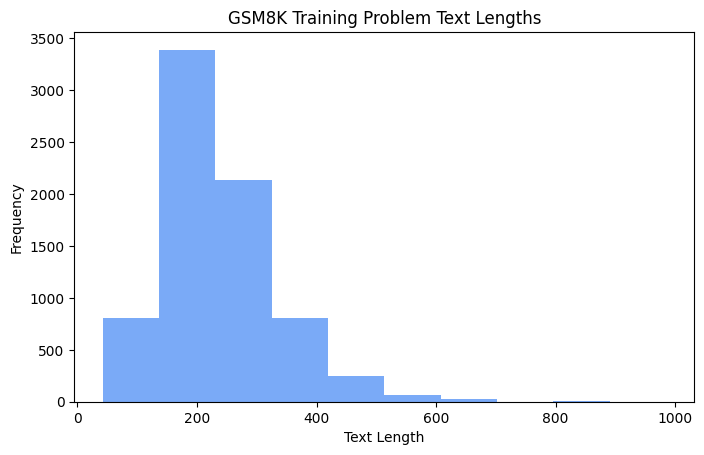

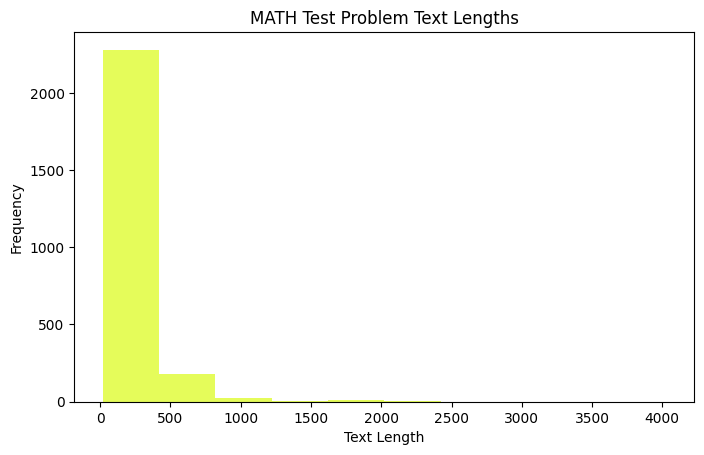

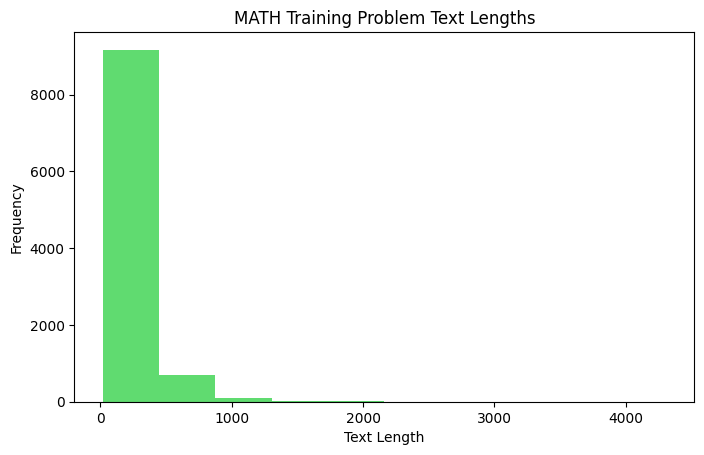

In [9]:
import matplotlib.pyplot as plt

gsm8k_test_problem_lengths=[]
gsm8k_train_problem_lengths=[]
math_test_problem_lengths=[]
math_train_problem_lengths=[]
##For the length of the problem, I am considering both the length of the body, and that of the actual question
#Get lengths of GSM8K
for i in range(0,len(gsm8k_test['question'])):
  gsm8k_test_problem_lengths.append(len(gsm8k_test['question'][i]))
for i in range(0,len(gsm8k_train['question'])):
  gsm8k_train_problem_lengths.append(len(gsm8k_train['question'][i]))
#And now MATH
for i in range(0,len(math_test['problem'])):
  math_test_problem_lengths.append(len(math_test['problem'][i]))
for i in range(0,len(math_train['problem'])):
  math_train_problem_lengths.append(len(math_train['problem'][i]))

#GSM8K Test Lengths
plt.figure(figsize=(8, 4.8))
plt.hist(gsm8k_test_problem_lengths, bins=10, alpha=0.7,color='#d6222e')
plt.title('GSM8K Test Problem Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()
#GSM8K Training lengths

plt.figure(figsize=(8, 4.8))
plt.hist(gsm8k_train_problem_lengths, bins=10, alpha=0.7,color='#4287f5')
plt.title('GSM8K Training Problem Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

#MATH Test Lengths
plt.figure(figsize=(8, 4.8))
plt.hist(math_test_problem_lengths, bins=10, alpha=0.7,color='#dafc14')
plt.title('MATH Test Problem Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()
#MATH Training lengths

plt.figure(figsize=(8, 4.8))
plt.hist(math_train_problem_lengths, bins=10, alpha=0.7,color='#1dcc34')
plt.title('MATH Training Problem Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

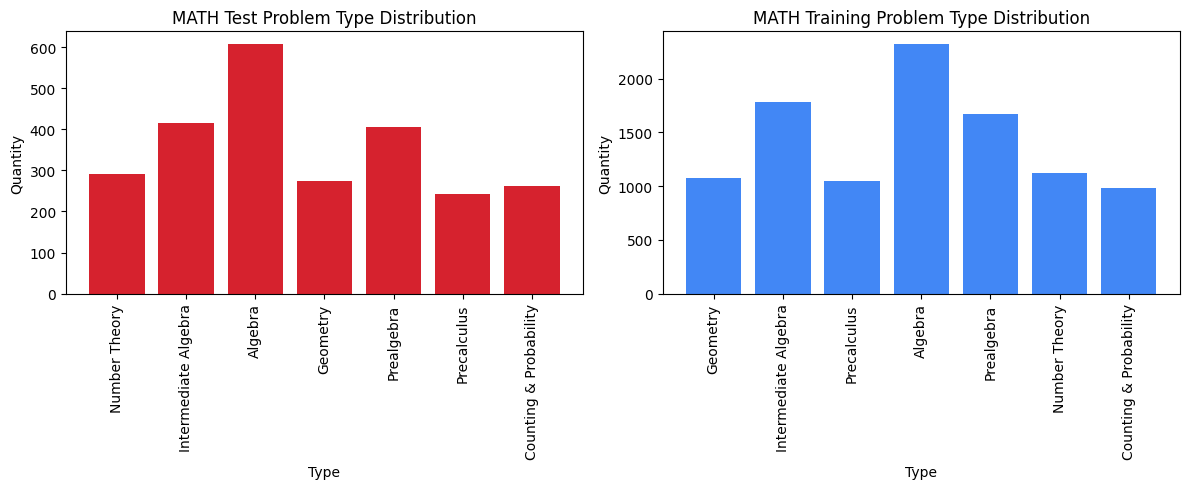

In [7]:
from collections import Counter

test_types=Counter(math_test["type"])
train_types=Counter(math_train["type"])
test_type=list(test_types.keys())
test_type_quantities=list(test_types.values())
train_type=list(train_types.keys())
train_type_quantities=list(train_types.values())

plt.figure(figsize=(12, 5))

#Testing Data
plt.subplot(1, 2, 1)
plt.bar(test_type,test_type_quantities,color='#d6222e')
plt.title('MATH Test Problem Type Distribution')
plt.xlabel('Type')
plt.ylabel('Quantity')
plt.xticks(rotation=90)

#Training Data
plt.subplot(1, 2, 2)
plt.bar(train_type,train_type_quantities,color='#4287f5')
plt.title('MATH Training Problem Type Distribution')
plt.xlabel('Type')
plt.ylabel('Quantity')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

##Note That this plot only includes the MATH dataset. Because GSM8k does not include a 'type' attribute, it is not included here